<a href="https://colab.research.google.com/github/Rimon-Roy/Alzheimer-s-diseases-Ditection/blob/main/alzheimer_s_efficientnetb0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import numpy as np
import scipy as sp
import pandas as pd
import seaborn as sns
from PIL import Image
import tensorflow as tf
import keras_cv
from tensorflow.data import AUTOTUNE
import tensorflow.keras as keras
import matplotlib.pyplot as plt
from tensorflow.keras.layers import (
    RandomBrightness, RandomZoom, RandomFlip,
    Input, Conv2D, BatchNormalization, MaxPool2D, Dropout, Flatten, Dense
)
from tensorflow.keras import layers
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import ReduceLROnPlateau, TensorBoard, ModelCheckpoint
from sklearn.model_selection import train_test_split


/opt/conda/lib/python3.10/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.24.3
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


Using TensorFlow backend


In [ ]:
# Load the dataset
X_loaded = np.load('/kaggle/input/alzheimer/X_final.npy')
Y_loaded = np.load('/kaggle/input/alzheimer/Y_final.npy')

In [ ]:
# Reshape and convert to RGB images
X_loaded_resized = np.resize(X_loaded, (len(X_loaded), 150, 150, 1))
X_loaded_rgb = np.repeat(X_loaded_resized, 3, axis=-1)

In [ ]:
from sklearn.utils import shuffle
X_train, y_train = shuffle(X_loaded_rgb, Y_loaded, random_state=42)
X_train.shape

(6400, 150, 150, 3)

In [ ]:
mean = np.mean(X_train)
std = np.std(X_train)

X_train = ((X_train - mean) / std).astype(np.float32)

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

In [ ]:
# Data augmentation
datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    featurewise_center=False,
    samplewise_center=False,
    featurewise_std_normalization=False,
    samplewise_std_normalization=False,
    zca_whitening=False,
    rotation_range=10,
    zoom_range=0.2,
    width_shift_range=0.2,
    horizontal_flip=False,
    vertical_flip=False
)

datagen.fit(X_train)

In [ ]:
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Flatten, BatchNormalization, Dropout, Dense, concatenate, Input
from tensorflow.keras.applications import EfficientNetB0
import tensorflow as tf

# Load EfficientNet model
base_model = EfficientNetB0(
    include_top=False,
    weights='imagenet',
    input_shape=(150, 150, 3)
)

for layer in base_model.layers:
    layer.trainable = True

# Additional layers
additional_model = Sequential()
additional_model.add(Flatten())
additional_model.add(BatchNormalization())
additional_model.add(Dropout(0.25))
additional_model.add(Dense(512, activation='relu'))
additional_model.add(BatchNormalization())
additional_model.add(Dropout(0.5))
additional_model.add(Dense(4, activation='softmax'))

# Create an input tensor for the EfficientNet base
efficientnet_input = Input(shape=(150, 150, 3))

# Connect the EfficientNet base
efficientnet_output = base_model(efficientnet_input)

# Flatten the EfficientNet output
efficientnet_output_flatten = Flatten()(efficientnet_output)

# Connect the EfficientNet output with the output of the additional layers
combined_output = concatenate([efficientnet_output_flatten, additional_model(efficientnet_input)])

# Final output layer
output = Dense(4, activation='softmax')(combined_output)

# Create the combined model
model = Model(inputs=efficientnet_input, outputs=output)

# Compile the model
optimizer = tf.keras.optimizers.Adam(lr=0.001, beta_1=0.9, beta_2=0.999, epsilon=0.1)
model.compile(loss='categorical_crossentropy', optimizer=optimizer, metrics=['accuracy'])

# Print model summary
model.summary()


16705208/16705208 [==============================] - 0s 0us/step
Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_2 (InputLayer)        [(None, 150, 150, 3)]        0         []                            
                                                                                                  
 efficientnetb0 (Functional  (None, 5, 5, 1280)           4049571   ['input_2[0][0]']             
 )                                                                                                
                                                                                                  
 flatten_1 (Flatten)         (None, 32000)                0         ['efficientnetb0[0][0]']      
                                                                                                  
 sequential (Sequential)     

In [ ]:
# Define callbacks
save_dir = '/kaggle/working/'
model_name = 'alzheimers_efficientnet.h5'
model_path = os.path.join(save_dir, model_name)

reduce_lr = ReduceLROnPlateau(monitor='val_accuracy', factor=0.8, patience=10)
tensorboard = TensorBoard(log_dir='logs')
checkpoint = ModelCheckpoint(model_path, monitor='val_accuracy', save_best_only=True, mode='auto', verbose=1)

# Train the model
history = model.fit(X_train, y_train, epochs=150, batch_size=32, validation_split=0.2, callbacks=[reduce_lr, tensorboard, checkpoint])


Epoch 1/150


2024-01-26 16:35:16.846402: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:954] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inmodel/efficientnetb0/block2b_drop/dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


128/128 [==============================] - ETA: 0s - loss: 1.0824 - accuracy: 0.5432
Epoch 1: val_accuracy improved from -inf to 0.15137, saving model to /kaggle/working/alzheimers_efficientnet.h5


/opt/conda/lib/python3.10/site-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


128/128 [==============================] - 61s 150ms/step - loss: 1.0824 - accuracy: 0.5432 - val_loss: 1.6874 - val_accuracy: 0.1514 - lr: 0.0010
Epoch 2/150
128/128 [==============================] - ETA: 0s - loss: 0.7402 - accuracy: 0.6848
Epoch 2: val_accuracy improved from 0.15137 to 0.16309, saving model to /kaggle/working/alzheimers_efficientnet.h5
128/128 [==============================] - 18s 141ms/step - loss: 0.7402 - accuracy: 0.6848 - val_loss: 1.7535 - val_accuracy: 0.1631 - lr: 0.0010
Epoch 3/150
128/128 [==============================] - ETA: 0s - loss: 0.5223 - accuracy: 0.7847
Epoch 3: val_accuracy improved from 0.16309 to 0.24023, saving model to /kaggle/working/alzheimers_efficientnet.h5
128/128 [==============================] - 17s 131ms/step - loss: 0.5223 - accuracy: 0.7847 - val_loss: 1.4375 - val_accuracy: 0.2402 - lr: 0.0010
Epoch 4/150
128/128 [==============================] - ETA: 0s - loss: 0.3504 - accuracy: 0.8645
Epoch 4: val_accuracy did not improve 

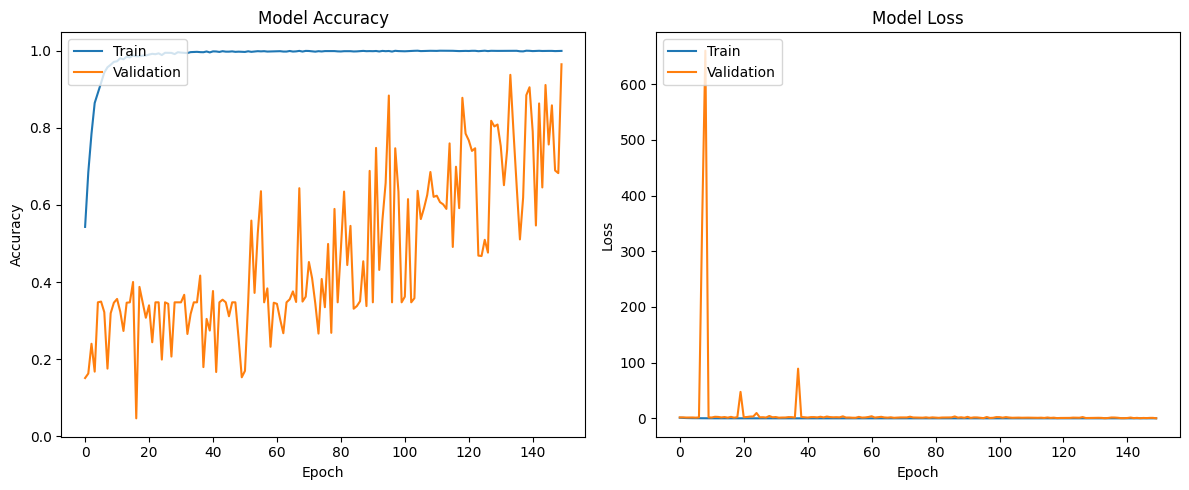

In [ ]:
# Plot training & validation accuracy values
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.tight_layout()
plt.show()

In [ ]:
class_names = ['MildDemented', 'ModerateDemented', 'NonDemented', 'VeryMildDemented']

from sklearn.metrics import confusion_matrix, classification_report

# Predict on validation data
y_pred = model.predict(X_test)

# Convert predictions and true labels back from one-hot encoding
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

classificationReports = classification_report(y_true_classes, y_pred_classes, target_names=class_names)
print("Classification Report:")
print(classificationReports)

40/40 [==============================] - 1s 24ms/step
Classification Report:
                  precision    recall  f1-score   support

    MildDemented       0.93      0.97      0.95       160
ModerateDemented       1.00      1.00      1.00        11
     NonDemented       0.95      0.98      0.97       633
VeryMildDemented       0.97      0.92      0.94       476

        accuracy                           0.96      1280
       macro avg       0.96      0.97      0.97      1280
    weighted avg       0.96      0.96      0.96      1280



In [ ]:
from sklearn.metrics import accuracy_score

# Calculate accuracy using accuracy_score
acc = accuracy_score(y_true_classes, y_pred_classes)
print("Accuracy:", acc)

Accuracy: 0.95703125


In [ ]:
conf_matrix = confusion_matrix(y_true_classes, y_pred_classes)
print("Confusion Matrix:")
print(conf_matrix)

Confusion Matrix:
[[155   0   2   3]
 [  0  11   0   0]
 [  2   0 622   9]
 [  9   0  30 437]]


Confusion matrix, without normalization


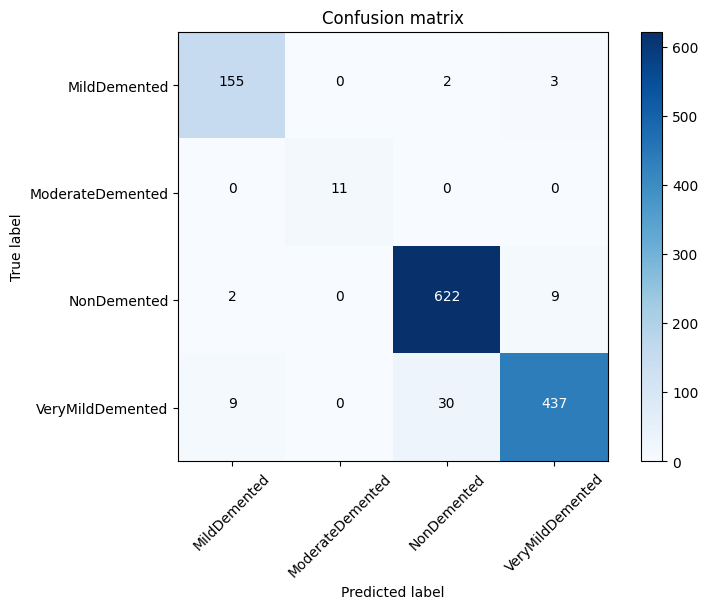

In [ ]:
import itertools

# Function to plot confusion matrix
def plot_confusion_matrix(cm, classes, normalize=False, title='Confusion matrix', cmap=plt.cm.Blues):
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, cm[i, j], horizontalalignment="center", color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

# Plot confusion matrix
plt.figure(figsize=(8, 6))
plot_confusion_matrix(conf_matrix, classes=class_names, normalize=False, title='Confusion matrix')
plt.show()

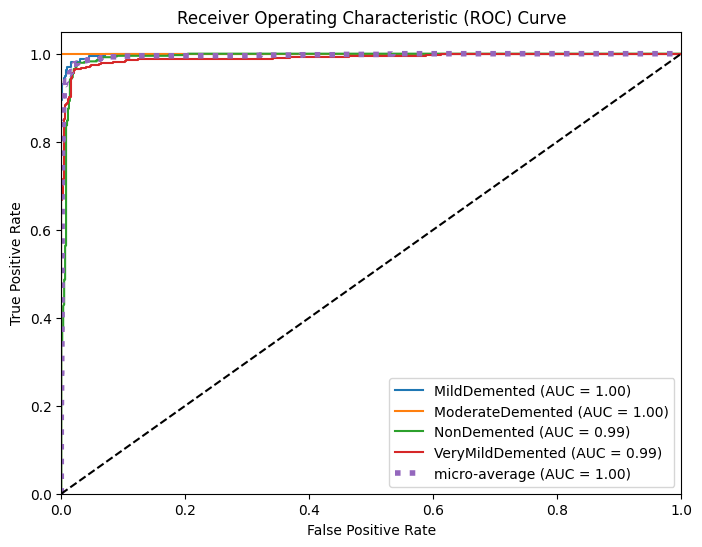

AUC-ROC (MildDemented): 0.9986
AUC-ROC (ModerateDemented): 1.0000
AUC-ROC (NonDemented): 0.9929
AUC-ROC (VeryMildDemented): 0.9902
AUC-ROC (micro-average): 0.9952


In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score, auc

# Compute ROC curve and ROC area for each class
n_classes = len(class_names)
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test[:, i], y_pred[:, i])
    roc_auc[class_names[i]] = auc(fpr[i], tpr[i])

# Compute micro-average ROC curve and ROC area
fpr["micro"], tpr["micro"], _ = roc_curve(y_test.ravel(), y_pred.ravel())
roc_auc['micro-average'] = auc(fpr["micro"], tpr["micro"])

# Plot ROC curve for each class
plt.figure(figsize=(8, 6))

for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], label=f'{class_names[i]} (AUC = {roc_auc[class_names[i]]:.2f})')

plt.plot(fpr["micro"], tpr["micro"], label='micro-average (AUC = {0:0.2f})'.format(roc_auc['micro-average']), linestyle=':', linewidth=4)

plt.plot([0, 1], [0, 1], 'k--')  # Random guess line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()

# Display AUC-ROC values
for class_name, auc_value in roc_auc.items():
    print(f'AUC-ROC ({class_name}): {auc_value:.4f}')


In [ ]:
# Calculate True Positives, False Positives, False Negatives for each class
tp = np.diag(conf_matrix)
fp = np.sum(conf_matrix, axis=0) - tp
fn = np.sum(conf_matrix, axis=1) - tp
# Calculate True Negatives (TN) for each class
tn = []
for i in range(len(conf_matrix)):
    temp = np.delete(conf_matrix, i, 0)  # Remove ith row
    temp = np.delete(temp, i, 1)  # Remove ith column
    tn.append(np.sum(temp))

# Calculate Recall, Precision, and F1-score for each class
recall = tp / (tp + fn)
precision = tp / (tp + fp)
f1_score = 2 * (precision * recall) / (precision + recall)

# Calculate average Recall, Precision, and F1-score
macro_avg_recall = np.mean(recall)
macro_avg_precision = np.mean(precision)
macro_avg_f1_score = np.mean(f1_score)

print(f"Macro-average Recall: {macro_avg_recall:.4f}")
print(f"Macro-average Precision: {macro_avg_precision:.4f}")
print(f"Macro-average F1-score: {macro_avg_f1_score:.4f}")

Macro-average Recall: 0.9674
Macro-average Precision: 0.9645
Macro-average F1-score: 0.9656


In [ ]:
# Calculate True Negatives for each class
tn = np.sum(conf_matrix) - (fp + fn + tp)

# Calculate Sensitivity (Recall) for each class
sensitivity = tp / (tp + fn)

# Calculate Specificity for each class
specificity = tn / (tn + fp)

# Calculate G-Mean for each class
g_mean = np.sqrt(sensitivity * specificity)

# Calculate average Sensitivity, Specificity, and G-Mean
avg_specificity = np.mean(specificity)
avg_g_mean = np.mean(g_mean)

print(f"Average Specificity: {avg_specificity:.4f}")
print(f"Average G-Mean: {avg_g_mean:.4f}")

Average Specificity: 0.9814
Average G-Mean: 0.9742


In [ ]:
def matthews_corr_coefficient(tp, tn, fp, fn):
    numerator = (tp * tn) - (fp * fn)
    denominator = np.sqrt((tp + fp) * (tp + fn) * (tn + fp) * (tn + fn))
    mcc = numerator / denominator if denominator != 0 else 0  # Handle division by zero
    return mcc

# Calculate MCC for each class against the rest
mcc_per_class = []
for i in range(len(tp)):
    tp_i, tn_i = tp[i], np.sum(np.delete(tp, i))  # True positives and true negatives for class i
    fp_i, fn_i = fp[i], np.sum(np.delete(fp, i))  # False positives and false negatives for class i

    mcc_i = matthews_corr_coefficient(tp_i, tn_i, fp_i, fn_i)
    mcc_per_class.append(mcc_i)

# Calculate average MCC across all classes
mcc_avg = np.mean(mcc_per_class)
print("Average MCC:", mcc_avg)

Average MCC: 0.7627317108106308
